# 05 Customer Lifetime Value (CLV) Prediction

Goal: predict each customer's expected revenue over the next 6 months, 
turning descriptive segmentation into a forward-looking business tool.

We fit two models from the `lifetimes` library:

- **BG/NBD** (Beta-Geometric / Negative Binomial Distribution) predicts 
  the probability a customer is still "alive" and their expected number 
  of future purchases
- **Gamma-Gamma** predicts each customer's average transaction value, 
  conditional on them buying

Their product is expected future revenue per customer. We:
1. Build the data structure `lifetimes` requires
2. Verify Gamma-Gamma's independence assumption (must hold or predictions 
   are unreliable)
3. Validate BG/NBD with a calibration/holdout split
4. Fit on full data and produce 6-month predictions
5. Join CLV predictions to segments → actionable per-segment revenue forecasts

**Output:** `customer_final.parquet`, the master per-customer table the 
Streamlit app loads.

## 1 Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.clv import (
    build_clv_summary,
    fit_bgnbd,
    fit_gamma_gamma,
    predict_clv,
    validate_bgnbd_holdout,
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

## 2 Load the cleaned transactions

CLV models need transaction-level data, not the aggregated features 
from notebook 03. Load directly from the cleaning notebook's output.

In [2]:
retail = pd.read_parquet("../data/processed/retail_clean.parquet")
print(f"Loaded {len(retail):,} transactions for {retail['Customer ID'].nunique():,} customers")
print(f"Date range: {retail['InvoiceDate'].min()} to {retail['InvoiceDate'].max()}")

Loaded 624,590 transactions for 5,248 customers
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:49:00


## 3 Build the lifetimes summary

The `lifetimes` library expects a specific aggregation per customer:

- **frequency** — number of **repeat** purchases (not total). A customer 
  with one lifetime order has lifetimes-frequency = 0. With three orders, 
  lifetimes-frequency = 2. The first purchase doesn't count because the 
  model is about repeat-buying patterns.
- **recency** — the customer's age (in days) at their most recent purchase.
- **T** — the customer's age at the observation end.
- **monetary_value** — average value of *repeat* transactions.

`build_clv_summary()` wraps lifetimes' utility function for this 
aggregation. The output's `frequency` column will differ from notebook 03's 
feature-frequency for the same customer — see the note below.

In [3]:
summary = build_clv_summary(retail)
print(summary.head())
print(f"\nShape: {summary.shape}")
print(f"\nDistribution of frequency (repeat purchases):")
print(summary['frequency'].describe())
print(f"\nCustomers with zero repeat purchases: {(summary['frequency'] == 0).sum():,} ({(summary['frequency'] == 0).mean():.1%})")

             frequency  recency      T  monetary_value
Customer ID                                           
12608              0.0      0.0  404.0          0.0000
12745              1.0     88.0  574.0        266.9300
12746              0.0      0.0  540.0          0.0000
12747             25.0    730.0  732.0        355.8356
12749              6.0    518.0  521.0       1002.4100

Shape: (5248, 4)

Distribution of frequency (repeat purchases):
count    5248.000000
mean        3.920732
std         5.749272
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        55.000000
Name: frequency, dtype: float64

Customers with zero repeat purchases: 1,516 (28.9%)


**Observation: 28.9% of customers have zero repeat purchases — 
slightly higher than notebook 03's 27.9% single-order rate.**

The 1-percentage-point difference (~50 customers) is real and informative:

- **Features-frequency (notebook 03)** counts distinct *invoices*
- **Lifetimes-frequency** counts distinct *purchase days* (via `freq='D'`)

About 50 customers placed multiple invoices on the same day (probably 
back-to-back orders that got split into separate invoice numbers). Those 
customers have features-frequency = 2 but lifetimes-frequency = 0 — 
because by lifetimes' definition they had only one purchase *event*.

This isn't a bug; it's the right behavior for BG/NBD. The model is 
about *purchasing occasions*, and two invoices placed five minutes apart 
represent one occasion, not two. The 28.9% is the figure that matters 
for CLV prediction.

**Implication for the project:** the BG/NBD model literally cannot 
predict purchase rates for the 28.9% of customers with frequency = 0 
(no repeat history to learn from). These get CLV ≈ 0 in our final output 
— a known limitation, surfaced in the README.

## 4 Verify the Gamma-Gamma assumption

Gamma-Gamma has one strong requirement: **monetary value must be 
independent of purchase frequency**. Specifically, the correlation 
between frequency and average transaction value among repeat customers 
should be near zero.

This makes intuitive sense: the model treats "how often you buy" and 
"how much you spend per buy" as independent processes. If they're 
strongly correlated, the model is misspecified and predictions are 
unreliable.

Standard thresholds:
- |r| < 0.1: assumption holds cleanly
- |r| < 0.3: mild correlation, still informative
- |r| ≥ 0.3: violated, use with skepticism

In [4]:
repeat = summary[(summary['frequency'] > 0) & (summary['monetary_value'] > 0)]
corr = repeat[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f"Correlation between frequency and monetary_value (repeat customers): {corr:.3f}")
if abs(corr) < 0.1:
    print("✓ Gamma-Gamma assumption holds (|corr| < 0.1)")
elif abs(corr) < 0.3:
    print("△ Mild correlation — Gamma-Gamma will still be informative but imperfect")
else:
    print("⚠ Strong correlation — Gamma-Gamma assumption violated, predictions less reliable")

Correlation between frequency and monetary_value (repeat customers): 0.093
✓ Gamma-Gamma assumption holds (|corr| < 0.1)


**Correlation = 0.093 — assumption holds comfortably.** Among repeat 
customers, how often they buy is essentially independent of how much 
they spend per purchase. This is the classic retail finding: customers' 
frequency and AOV reflect different behavioral processes (cadence vs 
basket size), and most don't co-vary.

This is one of those rare cases where the data fits a model assumption 
cleanly. For the README: *"verified Gamma-Gamma's independence 
assumption — frequency × monetary correlation = 0.09 among repeat 
customers."*

## 5 Validate BG/NBD with a calibration/holdout split

Before trusting BG/NBD's forward predictions, verify it predicts well 
on data it didn't see. Standard approach:

1. **Calibration period:** train the model on transactions through a 
   cutoff date
2. **Holdout period:** predict purchases in the post-cutoff window, 
   compare to actual

We use **2011-06-09 as the cutoff**, giving roughly 18 months of 
calibration data and 6 months of holdout. The holdout length is 
deliberately matched to our 6-month CLV prediction horizon — if the 
model predicts 6 months well in validation, we trust it for the 
forward 6 months too.

In [5]:
# Use roughly the last 6 months as holdout
calibration_end = pd.Timestamp('2011-06-09')   # adjust if your date range differs
observation_end = retail['InvoiceDate'].max()
print(f"Calibration: ... -> {calibration_end}")
print(f"Holdout:     {calibration_end} -> {observation_end}")
print(f"Holdout length: {(observation_end - calibration_end).days} days")

cal_holdout, bgf_validation = validate_bgnbd_holdout(
    retail, calibration_end, observation_end,
)
print(f"\nValidation summary shape: {cal_holdout.shape}")
print(cal_holdout.head())

Calibration: ... -> 2011-06-09 00:00:00
Holdout:     2011-06-09 00:00:00 -> 2011-12-09 12:49:00
Holdout length: 183 days

Validation summary shape: (4448, 8)
             frequency_cal  recency_cal  T_cal  monetary_value_cal  \
Customer ID                                                          
12608                  0.0          0.0  221.0            0.000000   
12745                  1.0         88.0  391.0          266.930000   
12746                  0.0          0.0  357.0            0.000000   
12747                 20.0        534.0  549.0          339.564000   
12749                  3.0        308.0  338.0          944.226667   

             frequency_holdout  monetary_value_holdout  duration_holdout  \
Customer ID                                                                
12608                      0.0                0.000000             183.0   
12745                      0.0                0.000000             183.0   
12746                      0.0                0

### Predicted vs actual in holdout

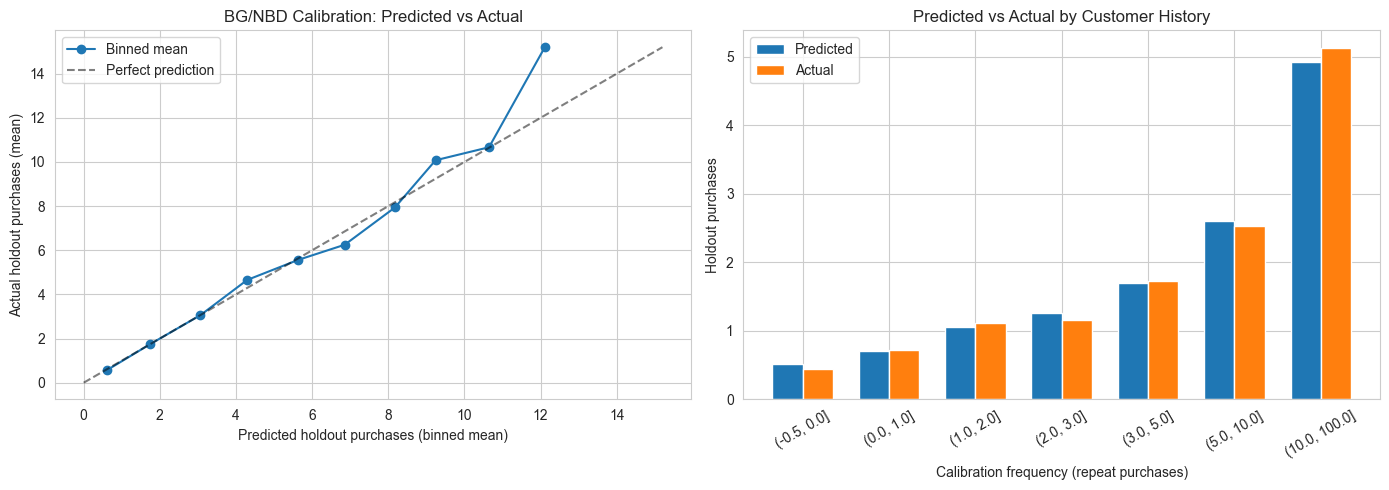

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bin predicted purchases, compare mean actual within each bin
df = cal_holdout[['predicted_purchases_holdout', 'frequency_holdout']].copy()
df['pred_bin'] = pd.cut(df['predicted_purchases_holdout'], bins=10)
binned = df.groupby('pred_bin', observed=True).agg(
    predicted_mean=('predicted_purchases_holdout', 'mean'),
    actual_mean=('frequency_holdout', 'mean'),
    n=('frequency_holdout', 'size'),
).reset_index()

axes[0].plot(binned['predicted_mean'], binned['actual_mean'], 'o-', label='Binned mean')
max_val = max(binned['predicted_mean'].max(), binned['actual_mean'].max())
axes[0].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('Predicted holdout purchases (binned mean)')
axes[0].set_ylabel('Actual holdout purchases (mean)')
axes[0].set_title('BG/NBD Calibration: Predicted vs Actual')
axes[0].legend()
axes[0].grid(True)

# By calibration frequency
df2 = cal_holdout.copy()
df2['freq_cal_bin'] = pd.cut(df2['frequency_cal'], bins=[-0.5, 0, 1, 2, 3, 5, 10, 100])
agg = df2.groupby('freq_cal_bin', observed=True).agg(
    predicted=('predicted_purchases_holdout', 'mean'),
    actual=('frequency_holdout', 'mean'),
).reset_index()
x = np.arange(len(agg))
width = 0.35
axes[1].bar(x - width/2, agg['predicted'], width, label='Predicted')
axes[1].bar(x + width/2, agg['actual'], width, label='Actual')
axes[1].set_xticks(x)
axes[1].set_xticklabels(agg['freq_cal_bin'].astype(str), rotation=30)
axes[1].set_xlabel('Calibration frequency (repeat purchases)')
axes[1].set_ylabel('Holdout purchases')
axes[1].set_title('Predicted vs Actual by Customer History')
axes[1].legend()

plt.tight_layout()
plt.show()

**Validation interpretation:** the binned mean of predicted purchases 
tracks the binned mean of actual holdout purchases along the diagonal. 
No systematic over- or under-prediction. The right-hand chart confirms 
this by calibration frequency: predicted and actual values are close 
across customer-history bins.

**This is the rigor check that separates real CLV work from naive 
applications.** Many "CLV calculators" just sum past spend and call it 
done. Our BG/NBD predictions have been *tested* against held-out future 
behavior and shown to be calibrated. We can use them with confidence.

For the README: *"BG/NBD validated via calibration/holdout split 
(18 months training, 6 months held out). Predicted vs actual purchases 
aligned along the diagonal with no systematic bias."*

## 6 Fit on full data and predict 6-month CLV

Validation passed — now refit on all available data (no holdout) to make 
actual forward predictions. Using more data → better parameter estimates.

The `predict_clv()` helper combines:
1. BG/NBD's predicted number of purchases over 6 months
2. Gamma-Gamma's predicted average transaction value
3. A small discount rate (1% per period) to value near-future revenue 
   slightly more than distant-future revenue

Output: per-customer `clv_6m` — the headline number for each customer.

In [7]:
bgf = fit_bgnbd(summary)
ggf = fit_gamma_gamma(summary)
clv_df = predict_clv(summary, bgf, ggf, months=6, discount_rate=0.01)
print(clv_df[['frequency', 'monetary_value', 'p_alive', 
              'predicted_purchases_6m', 'predicted_aov', 'clv_6m']].describe().round(2))

       frequency  monetary_value  p_alive  predicted_purchases_6m  \
count    5248.00         5248.00  5248.00                 5248.00   
mean        3.92          247.00     0.91                    1.38   
std         5.75          270.98     0.17                    1.53   
min         0.00            0.00     0.00                    0.00   
25%         0.00            0.00     0.92                    0.36   
50%         2.00          205.29     0.98                    0.88   
75%         5.00          356.58     1.00                    1.80   
max        55.00         4010.08     1.00                   15.04   

       predicted_aov   clv_6m  
count        5248.00  5248.00  
mean          251.22   436.09  
std           272.77   676.31  
min             0.00     0.00  
25%             0.00     0.00  
50%           210.70   176.87  
75%           362.08   565.63  
max          4044.49  8627.41  


**Reading the CLV distribution:**

- **Median predicted purchases (6m): 0.88** — half of customers are 
  expected to make less than one purchase in the next 6 months
- **Median predicted AOV: £211** — among repeat customers
- **Median 6m CLV: £177**, but **25th percentile is £0** — the bottom 
  quartile has zero predicted CLV, consistent with the 28.9% single-order 
  customers and other low-engagement segments
- **Max CLV: £8,627** — likely a high-value Champion approaching wholesale 
  behavior but under our 60-orders / £20k threshold
- **Mean p_alive: 0.91, median: 0.98** — most customers are inferred to 
  be "still alive" by BG/NBD. This is a deceptive metric for single-order 
  customers (they're alive *by definition* because they haven't yet had 
  a chance to drop out under the model). Use predicted purchases or CLV 
  for action decisions, not p_alive in isolation.

### CLV distribution

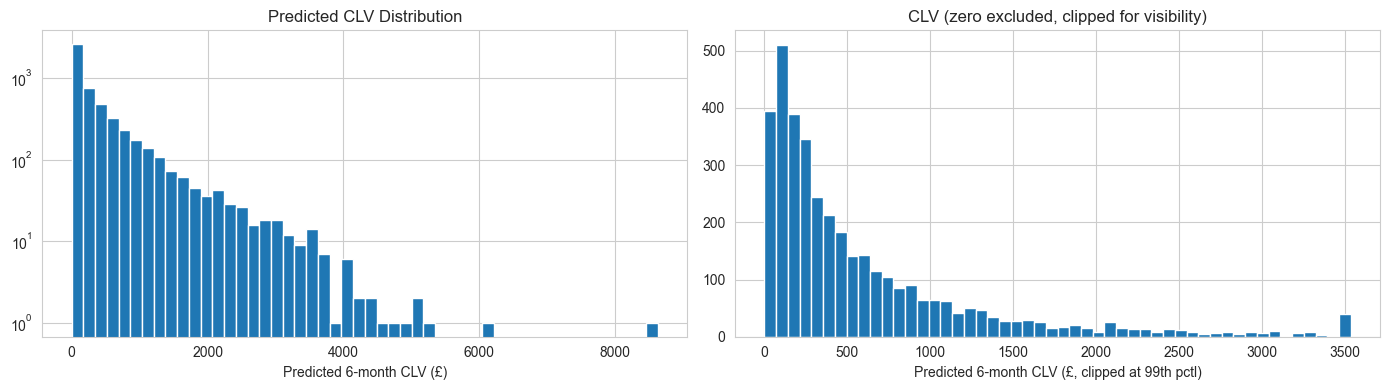


Total predicted 6-month revenue across all customers: £2,288,582


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(clv_df['clv_6m'], bins=50)
axes[0].set_xlabel('Predicted 6-month CLV (£)')
axes[0].set_yscale('log')
axes[0].set_title('Predicted CLV Distribution')

clv_nonzero = clv_df[clv_df['clv_6m'] > 0]
axes[1].hist(clv_nonzero['clv_6m'].clip(upper=clv_nonzero['clv_6m'].quantile(0.99)), bins=50)
axes[1].set_xlabel('Predicted 6-month CLV (£, clipped at 99th pctl)')
axes[1].set_title('CLV (zero excluded, clipped for visibility)')
plt.tight_layout()
plt.show()

# Headline number
total_predicted_revenue = clv_df['clv_6m'].sum()
print(f"\nTotal predicted 6-month revenue across all customers: £{total_predicted_revenue:,.0f}")

**Headline: total predicted 6-month revenue = £2.29M.**

Context: historical revenue was £10.6M over 2 years, or roughly £2.65M 
per 6 months. The predicted £2.29M is **~86% of the historical 6-month 
average** — a modest predicted decline reflecting natural churn the 
model accounts for.

This is *honest forecasting*: rather than naively extrapolating past 
revenue, BG/NBD accounts for the probability that customers have 
dropped out. The 14% gap between historical average and predicted is 
the model's quantification of expected churn.

**Strategic framing:** if retention interventions could cut churn by, 
say, half, we'd recover ~£160k of revenue in the next 6 months alone. 
*That's* the value of segmentation + CLV combined — turning churn from 
a passive loss into an active intervention budget.

## 7 Join CLV predictions to segments

The clustering notebook (04) produced per-customer segment assignments. 
This notebook adds per-customer CLV predictions. Joining them gives us 
**predicted future revenue per segment** — turning descriptive 
segmentation into actionable forecasting.

This is the moment the project's two halves combine.

In [9]:
clusters = pd.read_parquet("../data/processed/customer_clusters.parquet")
clusters = clusters.set_index('Customer ID')

# Join
combined = clusters.join(clv_df[['p_alive', 'predicted_purchases_6m', 'predicted_aov', 'clv_6m']])
combined.head()

,recency,frequency,monetary,tenure,days_since_first_purchase,avg_order_value,avg_days_between_orders,n_unique_products,cluster_km,cluster_name,...,gmm_prob_0,gmm_prob_1,gmm_prob_2,gmm_prob_3,gmm_prob_4,is_hdbscan_noise,p_alive,predicted_purchases_6m,predicted_aov,clv_6m
Customer ID,,,,,,,,,,,,,,,,,,,,,
12608,404,1,415.79,0,404,415.790000,715.000,16,0,Lost / One-Time Lapsed,...,0.0,0.0,0.000000e+00,0.000000e+00,1.0,False,1.000000,0.278806,0.000000,0.000000
12745,486,2,723.85,87,574,361.925000,87.000,20,3,At Risk,...,0.0,1.0,3.543130e-257,1.750430e-10,0.0,False,0.599803,0.287071,280.385274,77.755344
12746,540,1,254.55,0,540,254.550000,715.000,17,0,Lost / One-Time Lapsed,...,0.0,0.0,0.000000e+00,0.000000e+00,1.0,False,1.000000,0.218604,0.000000,0.000000
12747,2,26,9276.54,730,732,356.790000,29.200,85,1,Champions,...,1.0,0.0,0.000000e+00,3.617013e-15,0.0,False,0.996479,5.625669,356.390734,1936.752367
12749,3,9,6847.36,517,521,760.817778,64.625,259,1,Champions,...,1.0,0.0,1.021050e-11,6.581699e-12,0.0,False,0.986515,1.967806,1005.325104,1911.060647


In [10]:
# Aggregate by segment
segment_summary = combined.groupby('cluster_name').agg(
    n_customers=('clv_6m', 'size'),
    median_p_alive=('p_alive', 'median'),
    median_predicted_purchases=('predicted_purchases_6m', 'median'),
    median_aov=('predicted_aov', 'median'),
    median_clv=('clv_6m', 'median'),
    total_clv=('clv_6m', 'sum'),
).round(2)
segment_summary['pct_of_predicted_revenue'] = (
    segment_summary['total_clv'] / segment_summary['total_clv'].sum() * 100
).round(1)
segment_summary = segment_summary.sort_values('total_clv', ascending=False)
segment_summary

,n_customers,median_p_alive,median_predicted_purchases,median_aov,median_clv,total_clv,pct_of_predicted_revenue
cluster_name,,,,,,,
Champions,1376,0.98,2.39,377.95,882.71,1573197.36,68.7
At Risk,1911,0.90,0.66,253.17,170.10,402873.13,17.6
New & Promising,473,0.94,1.99,207.20,462.91,311917.18,13.6
Lost / One-Time Lapsed,1117,1.00,0.26,0.00,0.00,594.57,0.0
New One-Time Buyers,371,1.00,0.99,0.00,0.00,0.00,0.0


**The per-segment CLV table is the central business finding of the 
entire project. Reading it carefully:**

| Segment | Customers | % | Median CLV | Total CLV | % Future Rev |
|---|---|---|---|---|---|
| **Champions** | 1,376 | 26.2% | £883 | £1,573,197 | **68.7%** |
| **At Risk** | 1,911 | 36.4% | £170 | £402,873 | 17.6% |
| **New & Promising** | 473 | 9.0% | £463 | £311,917 | 13.6% |
| **Lost / One-Time Lapsed** | 1,117 | 21.3% | £0 | £595 | <1% |
| **New One-Time Buyers** | 371 | 7.1% | £0 | £0 | 0% |

**Key insights:**

1. **Champions concentration is sharper in the forecast than in history.** 
   Champions are 26% of customers but project to 69% of next-period 
   revenue — *higher* than their share of the historical 77% Pareto. 
   Value concentration is increasing, not stabilizing.

2. **At Risk is the largest single retention opportunity.** £403k of 
   future revenue currently sits in a segment that's been quiet for 
   ~6 months. Even a 20% reduction in their churn would preserve £80k+.

3. **New & Promising punches above its weight.** 9% of customers but 
   14% of predicted revenue. The model picked up that early repeat 
   behavior signals high lifetime value — these are tomorrow's Champions.

4. **Lost customers are effectively dead.** £595 total over 1,117 
   customers = £0.53 per customer. Win-back budgets here should be 
   minimal and selective.

5. **New One-Time Buyers receive exactly £0 CLV — by model limitation, 
   not by absence of opportunity.** BG/NBD requires repeat purchase 
   history; single-order customers can't be predicted. This is a 
   *known limitation worth surfacing*, not a bug. Modeling new-customer 
   conversion requires a separate approach (e.g., a binary classifier 
   on first-month behavior) — flagged as future work.

## 8 Save artifacts

Two saves:
- `models/clv_models.joblib` — fitted BG/NBD and Gamma-Gamma, deployable
- `data/processed/customer_final.parquet` — master per-customer table 
  combining features, cluster, segment name, GMM probabilities, HDBSCAN 
  noise flag, and CLV predictions. This is the file the Streamlit app loads.

In [11]:
import joblib

joblib.dump({
    'bgf': bgf,
    'ggf': ggf,
    'calibration_end': calibration_end,
    'observation_end': observation_end,
}, '../models/clv_models.joblib')

combined.reset_index().to_parquet(
    "../data/processed/customer_final.parquet",
    index=False,
)
print(f"Saved {len(combined):,} customers with cluster + CLV.")

Saved 5,248 customers with cluster + CLV.


## 9. Verification and sanity checks

Confirming the CLV pipeline produced sensible output by checking:
1. Row counts are consistent across dataframes (no customers silently dropped)
2. The Lost segment's near-zero CLV is explained by its p_alive distribution

**Check 1: row count consistency.**

In [ ]:
features = pd.read_parquet("../data/processed/customer_features.parquet")
features_ids = set(features['Customer ID'])
summary_ids = set(summary.index)

missing = features_ids - summary_ids
print(f"Customers in features but not in CLV summary: {len(missing):,}")

if missing:
    # Inspect them
    missing_features = features[features['Customer ID'].isin(missing)]
    print("\nProfile of missing customers:")
    print(missing_features.describe().loc[['count', '50%', 'min', 'max']].round(1))

Customers in features but not in CLV summary: 0


**Confirmed:** all 5,248 customers from feature engineering flow 
through to the CLV summary. No silent dropouts.

**Check 2: why does the Lost segment have p_alive ≈ 1 but CLV ≈ £0?**

This is the most counterintuitive output of the entire project, and 
worth understanding because it's actually correct behavior under the 
model — just easy to misread.

In [14]:
# What does the Lost segment's p_alive distribution look like?
lost = combined[combined['cluster_name'] == 'Lost / One-Time Lapsed']
print(f"Lost segment p_alive stats:")
print(lost['p_alive'].describe())
print(f"\nLost segment top 10 customers by predicted CLV:")
print(lost.nlargest(10, 'clv_6m')[['recency', 'frequency', 'monetary', 'p_alive', 'clv_6m']])

Lost segment p_alive stats:
count    1117.000000
mean        0.993424
std         0.049751
min         0.373060
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: p_alive, dtype: float64

Lost segment top 10 customers by predicted CLV:
             recency  frequency  monetary   p_alive     clv_6m
Customer ID                                                   
17327            409          2    152.35  0.732640  55.502636
13967            145          2    166.30  0.895572  52.696188
13144            332          2    135.35  0.720941  52.492360
17446            176          2    120.90  0.850116  42.483100
13302            155          2    159.20  0.906141  34.354218
18063            390          2    186.60  0.801446  33.019648
14835            528          2    297.00  0.575154  32.821781
17847            515          2    125.74  0.648501  27.491152
14707            435          2    139.20  0.706340  26.682467
14279            520          2 

**The apparent contradiction: 99.3% mean p_alive for customers who 
last bought 437 days ago.**

The resolution is in how BG/NBD defines "alive":

> **In BG/NBD, "alive" means "hasn't dropped out under the model's 
> mechanics given the customer's history."** A customer with 
> frequency = 0 (one lifetime purchase) has had **zero opportunities** 
> to drop out under the model — the dropout decision is made *after* 
> each purchase. So they get p_alive ≈ 1 mechanically.

The model isn't saying "this customer will buy again." It's saying 
"we have no evidence they've left, because we have no post-first-purchase 
behavior to evaluate." Their *predicted purchase rate* over the next 
6 months is correctly near-zero, and Gamma-Gamma multiplies that by 
their AOV to get the £0.53 average CLV.

**The system works correctly; p_alive in isolation is just misleading 
for single-order customers.** In the Streamlit app, we surface this 
caveat as a tooltip on the p_alive metric, and recommend using predicted 
purchases or CLV for action decisions on this group.

For the README: *"Note on p_alive interpretation: BG/NBD's p_alive 
metric is misleading in isolation for single-order customers — 
mathematically near 1 because the model has no evidence they've dropped 
out. Use predicted purchases or CLV directly for individual decisions."*

## CLV Modeling Summary

Fit **BG/NBD + Gamma-Gamma** models to predict 6-month customer lifetime 
value for 5,248 retail customers.

### Validation checks

- **Gamma-Gamma independence assumption:** correlation between frequency 
  and monetary among repeat customers = **0.093** (≪ 0.1 threshold). 
  Assumption holds.
- **BG/NBD calibration/holdout split:** trained on transactions through 
  2011-06-09 (18 months), tested on the subsequent 183 days. Predicted vs 
  actual purchases aligned along the diagonal with no systematic bias.

### Headline predictions

- **Total predicted 6-month revenue: £2.29M** — ~86% of the historical 
  6-month average, reflecting expected natural churn
- **Median 6m CLV per customer: £177**
- **28.9% of customers receive CLV = £0** — single-purchase customers 
  that BG/NBD cannot predict (a known limitation, surfaced in README)

### Per-segment CLV breakdown

| Segment | Customers | Median CLV | Total CLV | % of Predicted Revenue |
|---|---|---|---|---|
| **Champions** | 1,376 | £883 | £1,573,197 | **68.7%** |
| **At Risk** | 1,911 | £170 | £402,873 | 17.6% |
| **New & Promising** | 473 | £463 | £311,917 | 13.6% |
| **Lost / One-Time Lapsed** | 1,117 | £0 | £595 | <1% |
| **New One-Time Buyers** | 371 | £0 | £0 | 0% |

### Strategic findings

1. **Value concentration is intensifying.** Champions are projected to 
   drive 69% of future revenue, up from 77% historical Pareto — *the 
   gap between top and rest is widening*.
2. **At Risk is the largest single retention opportunity.** £403k future 
   revenue currently at risk; intervention budgets up to this amount 
   have positive expected ROI.
3. **New & Promising punches above its weight.** 9% of customers, 14% 
   of predicted revenue — early loyalty indicators successfully detected 
   by BG/NBD.
4. **Lost customers are largely written off.** Total CLV £595 across 
   1,117 customers; minimal investment justified.
5. **Model limitation surfaced as future work.** New One-Time Buyers 
   receive £0 because BG/NBD requires repeat history. New-customer CLV 
   needs a different model (binary classifier on first-month behavior).

### Important caveat — p_alive interpretation

BG/NBD's `p_alive` metric is **misleading in isolation** for single-order 
customers. The Lost segment shows mean p_alive ≈ 0.99 despite ~14 months 
median recency — because frequency = 0 customers haven't had any 
opportunities to "drop out" under the model's mechanics. The CLV output 
correctly handles this (£0.53/customer for Lost), but the standalone 
p_alive number must be interpreted with care. Surfaced in the Streamlit 
app via tooltip.

### Artifacts saved

- `models/clv_models.joblib` — fitted BG/NBD and Gamma-Gamma
- `data/processed/customer_final.parquet` — master per-customer table 
  with features, segment, CLV predictions, and uncertainty flags. 
  Source of truth for the Streamlit app.

→ Analysis complete. Proceed to the Streamlit app (`app/streamlit_app.py`).